# Small Pest Dataset Classification Notebook

This notebook is modified for your **5 classes**:

- `leaf_minor_adult`
- `not_disease`
- `tobacco_catterpillar`
- `tomato_bollworm`
- `whitefly`

Because your dataset is small, this notebook uses a safe transfer-learning pipeline:

- corrupted image checking
- duplicate / near-duplicate checking using pHash
- stratified train/validation split
- optional physical split folders: `pest_train_validation_split/train` and `pest_train_validation_split/validation`
- RGB resize preprocessing
- moderate pest-safe augmentation
- class weights for imbalance
- MobileNetV2 first with careful fine-tuning
- optional EfficientNetB0 comparison

No HSV green leaf masking is used because pest images may contain leaf, fruit, wall, soil, lab background, or non-disease images.


In [1]:
# ============================================================
# 1. IMPORTS AND CONFIGURATION
# ============================================================

import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

ImageFile.LOAD_TRUNCATED_IMAGES = True

# Install imagehash if needed:
# !pip install imagehash
try:
    import imagehash
    HASHING_AVAILABLE = True
except ImportError:
    HASHING_AVAILABLE = False
    print("imagehash is not installed. Run this first: !pip install imagehash")

# ------------------------------------------------------------
# Dataset path
# ------------------------------------------------------------
# Use "." if this notebook is directly inside your dataset folder.
# Your folder should look like:
#
# PEST_DATASET/
# ├── leaf_minor_adult/
# ├── not_disease/
# ├── tobacco_catterpillar/
# ├── tomato_bollworm/
# ├── whitefly/
# ├── new.ipynb
# └── pest.ipynb

DATA_DIR = "."

# Exact class folder names from your screenshot.
CLASS_NAMES = [
    "leaf_minor_adult",
    "not_disease",
    "tobacco_catterpillar",
    "tomato_bollworm",
    "whitefly"
]

IGNORE_FOLDERS = {
    "train", "test", "validation", "val",
    "pest_train_validation_split",
    "_annotations", "annotations", "__pycache__",
    ".ipynb_checkpoints"
}

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

IMG_SIZE = 224

# Best safe starting value for a small dataset.
# Use 8 for stable training. If your GPU is strong, try 16 later.
BATCH_SIZE = 8

SEED = 42

# Small dataset: do not train for too long.
# EarlyStopping will stop automatically when validation loss stops improving.
EPOCHS_HEAD = 20
EPOCHS_FINE = 10

# Good starting learning rates for transfer learning on a small dataset.
LEARNING_RATE_HEAD = 1e-4
LEARNING_RATE_FINE = 1e-5

# Use MobileNetV2 first for small data.
# Set True only after MobileNetV2 works properly.
TRAIN_EFFICIENTNETB0_TOO = False

# Train/validation split settings.
VAL_RATIO = 0.20
SPLIT_DIR = os.path.join(DATA_DIR, "pest_train_validation_split")
CREATE_SPLIT_FOLDERS = True

# If True, old SPLIT_DIR will be deleted and recreated.
# Keep True when you change class folders or add new images.
OVERWRITE_SPLIT_FOLDERS = True

# Cleaning options.
# Keep False first so you can preview. Change to True only after checking the output.
DELETE_BAD_IMAGES = False
DELETE_DUPLICATES = False

# 0 = exact pHash duplicate.
# 3 or 4 = near duplicate. Use near duplicate carefully.
PHASH_THRESHOLD = 0

# Cache resized images in memory for faster training.
# Keep True for small datasets.
CACHE_DATASET = True

AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Dataset path:", os.path.abspath(DATA_DIR))
print("Classes:", CLASS_NAMES)


TensorFlow version: 2.21.0
Dataset path: c:\Users\user\Desktop\pest_dataset
Classes: ['leaf_minor_adult', 'not_disease', 'tobacco_catterpillar', 'tomato_bollworm', 'whitefly']


In [2]:
# ============================================================
# 2. CHECK CLASS FOLDERS
# ============================================================

available_folders = [
    f for f in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, f)) and f not in IGNORE_FOLDERS
]

missing_classes = [
    c for c in CLASS_NAMES
    if not os.path.isdir(os.path.join(DATA_DIR, c))
]

if missing_classes:
    print("Missing class folders:")
    for c in missing_classes:
        print("-", c)
    print("\nAvailable folders:")
    for f in available_folders:
        print("-", f)
    raise ValueError("Some class folders are missing. Check spelling and DATA_DIR.")

print("Classes used:")
for i, class_name in enumerate(CLASS_NAMES):
    print(i, "-->", class_name)


Classes used:
0 --> leaf_minor_adult
1 --> not_disease
2 --> tobacco_catterpillar
3 --> tomato_bollworm
4 --> whitefly


In [3]:
# ============================================================
# 3. CHECK / REMOVE CORRUPTED IMAGES
# ============================================================

def check_corrupted_images(data_dir, class_names, delete=False):
    bad_images = []

    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)

        for root, dirs, files in os.walk(class_path):
            for file in files:
                if file.lower().endswith(VALID_EXTENSIONS):
                    path = os.path.join(root, file)

                    try:
                        with Image.open(path) as img:
                            img.verify()
                    except Exception:
                        bad_images.append(path)

    print("Corrupted images found:", len(bad_images))

    for path in bad_images[:30]:
        print(path)

    if len(bad_images) > 30:
        print("... more corrupted images not shown")

    if delete:
        for path in bad_images:
            try:
                os.remove(path)
            except Exception as e:
                print("Could not remove:", path, e)
        print("Corrupted images removed.")
    else:
        print("Preview only. Set DELETE_BAD_IMAGES = True to delete.")

    return bad_images

bad_images = check_corrupted_images(DATA_DIR, CLASS_NAMES, delete=DELETE_BAD_IMAGES)


Corrupted images found: 0
Preview only. Set DELETE_BAD_IMAGES = True to delete.


In [4]:
# ============================================================
# 4. CHECK / REMOVE DUPLICATE IMAGES USING pHASH
# ============================================================

def find_duplicate_images(data_dir, class_names, threshold=0, delete=False):
    if not HASHING_AVAILABLE:
        print("Skipping duplicate check because imagehash is not installed.")
        print("Run: !pip install imagehash")
        return []

    seen = []   # (hash, path, class_name)
    duplicates = []
    cross_class_duplicates = []

    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)

        for root, dirs, files in os.walk(class_path):
            for file in files:
                if file.lower().endswith(VALID_EXTENSIONS):
                    path = os.path.join(root, file)

                    try:
                        with Image.open(path) as img:
                            img = img.convert("RGB")
                            img_hash = imagehash.phash(img)

                        matched = False

                        for old_hash, old_path, old_class in seen:
                            distance = img_hash - old_hash

                            if distance <= threshold:
                                duplicates.append({
                                    "remove_candidate": path,
                                    "kept_image": old_path,
                                    "remove_class": class_name,
                                    "kept_class": old_class,
                                    "distance": distance
                                })

                                if class_name != old_class:
                                    cross_class_duplicates.append((path, old_path, class_name, old_class, distance))

                                matched = True
                                break

                        if not matched:
                            seen.append((img_hash, path, class_name))

                    except Exception as e:
                        print("Hashing error:", path, e)

    print("Duplicate / near-duplicate images found:", len(duplicates))
    print("Cross-class duplicate conflicts found:", len(cross_class_duplicates))

    print("\nSample duplicate candidates:")
    for item in duplicates[:20]:
        print("REMOVE candidate:", item["remove_candidate"])
        print("KEPT image      :", item["kept_image"])
        print("Class pair      :", item["remove_class"], "vs", item["kept_class"])
        print("pHash distance  :", item["distance"])
        print("---")

    if cross_class_duplicates:
        print("\nWARNING: Cross-class duplicates exist.")
        print("These are dangerous because the same/similar image appears in different labels.")
        print("Check them manually before deleting.")

    if delete:
        for item in duplicates:
            try:
                os.remove(item["remove_candidate"])
            except Exception as e:
                print("Could not remove:", item["remove_candidate"], e)
        print("Duplicate candidates removed.")
    else:
        print("Preview only. Set DELETE_DUPLICATES = True to delete.")

    return duplicates

duplicates = find_duplicate_images(
    DATA_DIR,
    CLASS_NAMES,
    threshold=PHASH_THRESHOLD,
    delete=DELETE_DUPLICATES
)


Duplicate / near-duplicate images found: 17
Cross-class duplicate conflicts found: 0

Sample duplicate candidates:
REMOVE candidate: .\tobacco_catterpillar\SI (64).jpg
KEPT image      : .\tobacco_catterpillar\SI (55).jpg
Class pair      : tobacco_catterpillar vs tobacco_catterpillar
pHash distance  : 0
---
REMOVE candidate: .\tobacco_catterpillar\SI flipud (18).jpg
KEPT image      : .\tobacco_catterpillar\SI fliplr (66).jpg
Class pair      : tobacco_catterpillar vs tobacco_catterpillar
pHash distance  : 0
---
REMOVE candidate: .\tobacco_catterpillar\SI flipud (64).jpg
KEPT image      : .\tobacco_catterpillar\SI flipud (55).jpg
Class pair      : tobacco_catterpillar vs tobacco_catterpillar
pHash distance  : 0
---
REMOVE candidate: .\tobacco_catterpillar\SI flipud (66).jpg
KEPT image      : .\tobacco_catterpillar\SI fliplr (18).jpg
Class pair      : tobacco_catterpillar vs tobacco_catterpillar
pHash distance  : 0
---
REMOVE candidate: .\tobacco_catterpillar\SI90 (18).jpg
KEPT image      

In [5]:
# ============================================================
# 5. COLLECT IMAGE PATHS AND LABELS
# ============================================================

image_paths = []
labels = []

print("Image count per class:")

class_counts = {}

for label_id, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(DATA_DIR, class_name)
    class_images = []

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(VALID_EXTENSIONS):
                full_path = os.path.join(root, file)
                class_images.append(full_path)

    class_images = sorted(class_images)
    class_counts[class_name] = len(class_images)

    image_paths.extend(class_images)
    labels.extend([label_id] * len(class_images))

    print(f"{class_name} --> {len(class_images)} images")

image_paths = np.array(image_paths)
labels = np.array(labels)

print("\nTotal usable images:", len(image_paths))

if len(image_paths) == 0:
    raise ValueError("No images found. Check DATA_DIR and image extensions.")

unique_labels, counts = np.unique(labels, return_counts=True)

if len(unique_labels) != len(CLASS_NAMES):
    found = [CLASS_NAMES[i] for i in unique_labels]
    raise ValueError(f"Some classes have no images. Found classes: {found}")

if np.any(counts < 2):
    raise ValueError(
        "Each class needs at least 2 images for stratified splitting. "
        f"Counts: {dict(zip([CLASS_NAMES[i] for i in unique_labels], counts))}"
    )

print("\nSmall dataset warning:")
for class_name, count in class_counts.items():
    if count < 30:
        print(f"- {class_name}: only {count} images. Add more images if possible.")


Image count per class:
leaf_minor_adult --> 235 images
not_disease --> 720 images
tobacco_catterpillar --> 672 images
tomato_bollworm --> 756 images
whitefly --> 420 images

Total usable images: 2803

Small dataset warning:


In [6]:
# ============================================================
# 6. TRAIN / VALIDATION SPLIT + OPTIONAL FOLDER CREATION
# ============================================================

# For a small dataset, keep only train and validation.
# Do not create a separate test set unless you have many images.
# The split is stratified, so every class is represented in both train and validation.

num_classes = len(CLASS_NAMES)
total_images = len(image_paths)

# At least one validation image per class.
min_val_ratio = num_classes / total_images
test_size = max(VAL_RATIO, min_val_ratio)

# Avoid making validation too large for a small dataset.
test_size = min(test_size, 0.30)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=test_size,
    random_state=SEED,
    stratify=labels
)

print("Dataset split:")
print("Train images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Validation ratio used:", round(test_size, 3))

print("\nPer-class split count:")
for i, class_name in enumerate(CLASS_NAMES):
    print(
        class_name,
        "| train:", int(np.sum(train_labels == i)),
        "| validation:", int(np.sum(val_labels == i))
    )

# ------------------------------------------------------------
# Optional: create real train/validation folders
# ------------------------------------------------------------
# This is useful because you can visually check the split folders.
# Training below still uses train_paths and val_paths directly.

def copy_split_to_folders(train_paths, val_paths, train_labels, val_labels):
    if os.path.exists(SPLIT_DIR) and OVERWRITE_SPLIT_FOLDERS:
        shutil.rmtree(SPLIT_DIR)

    for split_name in ["train", "validation"]:
        for class_name in CLASS_NAMES:
            os.makedirs(os.path.join(SPLIT_DIR, split_name, class_name), exist_ok=True)

    def copy_files(paths, labels_arr, split_name):
        for src_path, label_id in zip(paths, labels_arr):
            class_name = CLASS_NAMES[int(label_id)]
            filename = os.path.basename(src_path)
            dst_path = os.path.join(SPLIT_DIR, split_name, class_name, filename)

            # Avoid overwriting if two files have the same filename.
            if os.path.exists(dst_path):
                name, ext = os.path.splitext(filename)
                dst_path = os.path.join(
                    SPLIT_DIR,
                    split_name,
                    class_name,
                    f"{name}_{abs(hash(src_path)) % 100000}{ext}"
                )

            shutil.copy2(src_path, dst_path)

    copy_files(train_paths, train_labels, "train")
    copy_files(val_paths, val_labels, "validation")

    print("\nSplit folders created successfully:")
    print(os.path.abspath(SPLIT_DIR))

if CREATE_SPLIT_FOLDERS:
    copy_split_to_folders(train_paths, val_paths, train_labels, val_labels)


Dataset split:
Train images: 2242
Validation images: 561
Validation ratio used: 0.2

Per-class split count:
leaf_minor_adult | train: 188 | validation: 47
not_disease | train: 576 | validation: 144
tobacco_catterpillar | train: 537 | validation: 135
tomato_bollworm | train: 605 | validation: 151
whitefly | train: 336 | validation: 84

Split folders created successfully:
c:\Users\user\Desktop\pest_dataset\pest_train_validation_split


In [7]:
# ============================================================
# 7. CLASS WEIGHTS FOR CLASS IMBALANCE
# ============================================================

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(np.unique(train_labels), class_weights_values)
}

print("Class weights:")
for i, weight in class_weights.items():
    print(f"{CLASS_NAMES[i]}: {weight:.4f}")


Class weights:
leaf_minor_adult: 2.3851
not_disease: 0.7785
tobacco_catterpillar: 0.8350
tomato_bollworm: 0.7412
whitefly: 1.3345


In [8]:
# ============================================================
# 8. IMAGE LOADING FUNCTION
# ============================================================

# Pest-safe preprocessing:
# 1. Read image
# 2. Convert to RGB
# 3. Resize to 224 x 224
# 4. Keep raw float image
#
# Do not use HSV leaf masking here.

def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image, label


In [9]:
# ============================================================
# 9. CREATE TF.DATA DATASETS
# ============================================================

def create_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    # Cache helps small datasets train faster after the first epoch.
    if CACHE_DATASET:
        ds = ds.cache()

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = create_dataset(train_paths, train_labels, training=True)
val_ds = create_dataset(val_paths, val_labels, training=False)

print("train_ds and val_ds created successfully.")
print("Batch size:", BATCH_SIZE)


train_ds and val_ds created successfully.
Batch size: 8


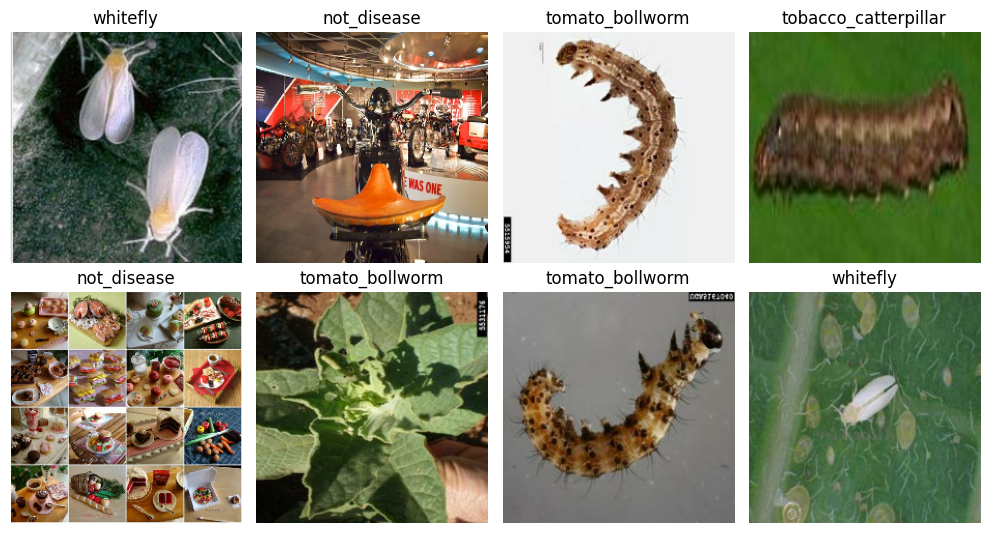

In [10]:
# ============================================================
# 10. SHOW SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(10, 8))

for images, batch_labels in train_ds.take(1):
    sample_count = min(12, images.shape[0])

    for i in range(sample_count):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(batch_labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()


In [11]:
# ============================================================
# 11. DATA AUGMENTATION
# ============================================================

# Safe augmentations for a small pest dataset.
# Keep augmentation moderate because the pest may be small.
# Do not use vertical flip by default because insects have natural orientation.

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.07),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomBrightness(0.10),
], name="data_augmentation")


In [12]:
# ============================================================
# 12. MODEL BUILDER
# ============================================================

def build_model(model_name, num_classes):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = data_augmentation(inputs)

    if model_name == "MobileNetV2":
        x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

        base_model = tf.keras.applications.MobileNetV2(
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            include_top=False,
            weights="imagenet"
        )

    elif model_name == "EfficientNetB0":
        # EfficientNetB0 has preprocessing built into the model in tf.keras.
        base_model = tf.keras.applications.EfficientNetB0(
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            include_top=False,
            weights="imagenet"
        )

    else:
        raise ValueError("model_name must be 'MobileNetV2' or 'EfficientNetB0'")

    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.35)(x)

    # Small dense layer helps learn pest-specific features without making the model too heavy.
    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )(x)

    model = tf.keras.Model(inputs, outputs)
    return model, base_model


In [13]:
# ============================================================
# 13. PLOT TRAINING CURVES
# ============================================================

def plot_training_curves(history_head, history_fine, model_name):
    acc = history_head.history.get("accuracy", []) + history_fine.history.get("accuracy", [])
    val_acc = history_head.history.get("val_accuracy", []) + history_fine.history.get("val_accuracy", [])

    loss = history_head.history.get("loss", []) + history_fine.history.get("loss", [])
    val_loss = history_head.history.get("val_loss", []) + history_fine.history.get("val_loss", [])

    plt.figure(figsize=(8, 5))
    plt.plot(acc, label="Training Accuracy")
    plt.plot(val_acc, label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{model_name}_accuracy.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(loss, label="Training Loss")
    plt.plot(val_loss, label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{model_name}_loss.png", dpi=300, bbox_inches="tight")
    plt.show()


In [14]:
# ============================================================
# 14. VALIDATION EVALUATION FUNCTION
# ============================================================

def evaluate_model(best_model, val_ds, model_name):
    print("\nEvaluating best model on validation set:")

    val_loss, val_acc = best_model.evaluate(val_ds, verbose=1)

    print(f"\n{model_name} Validation Accuracy: {val_acc * 100:.2f}%")
    print(f"{model_name} Validation Loss: {val_loss:.4f}")

    y_true = []
    y_pred = []

    for images, labels_batch in val_ds:
        predictions = best_model.predict(images, verbose=0)
        predicted_labels = np.argmax(predictions, axis=1)

        y_true.extend(labels_batch.numpy())
        y_pred.extend(predicted_labels)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, xticks_rotation=45, values_format="d")
    plt.title(f"{model_name} Validation Confusion Matrix")
    plt.savefig(f"{model_name}_validation_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    return val_loss, val_acc


In [15]:
# ============================================================
# 15. TRAINING FUNCTION
# ============================================================

def train_model(model_name):
    print("\n" + "=" * 60)
    print(f"Training started for: {model_name}")
    print("=" * 60)

    num_classes = len(CLASS_NAMES)
    model, base_model = build_model(model_name, num_classes)

    # Sparse categorical crossentropy is correct because labels are integers:
    # 0, 1, 2, 3, 4
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_HEAD),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    checkpoint_path = f"best_{model_name}.keras"

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]

    print("\nStage 1: Training classifier head only")
    print("Learning rate:", LEARNING_RATE_HEAD)

    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_HEAD,
        callbacks=callbacks,
        class_weight=class_weights
    )

    print("\nStage 2: Fine-tuning last layers")

    base_model.trainable = True

    # Small dataset rule:
    # Fine-tune only the last few layers.
    # Do not unfreeze the full backbone, or it can overfit quickly.
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    # Keep BatchNorm frozen for stable fine-tuning.
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_FINE),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    print("Learning rate:", LEARNING_RATE_FINE)

    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_HEAD + EPOCHS_FINE,
        initial_epoch=len(history_head.history["loss"]),
        callbacks=callbacks,
        class_weight=class_weights
    )

    best_model = tf.keras.models.load_model(checkpoint_path)

    val_loss, val_acc = evaluate_model(
        best_model=best_model,
        val_ds=val_ds,
        model_name=model_name
    )

    plot_training_curves(history_head, history_fine, model_name)

    return {
        "model_name": model_name,
        "validation_loss": val_loss,
        "validation_accuracy": val_acc,
        "model_path": checkpoint_path
    }



Training started for: MobileNetV2

Stage 1: Training classifier head only
Learning rate: 0.0001
Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.3956 - loss: 1.8518
Epoch 1: val_loss improved from None to 0.53786, saving model to best_MobileNetV2.keras
281/281 ━━━━━━━━━━━━━━━━━━━━ 77s 257ms/step - accuracy: 0.5241 - loss: 1.4177 - val_accuracy: 0.8182 - val_loss: 0.5379 - learning_rate: 1.0000e-04
Epoch 2/20
280/281 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7489 - loss: 0.7172
Epoch 2: val_loss improved from 0.53786 to 0.40167, saving model to best_MobileNetV2.keras
281/281 ━━━━━━━━━━━━━━━━━━━━ 50s 178ms/step - accuracy: 0.7591 - loss: 0.7119 - val_accuracy: 0.8770 - val_loss: 0.4017 - learning_rate: 1.0000e-04
Epoch 3/20
280/281 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7903 - loss: 0.5696
Epoch 3: val_loss improved from 0.40167 to 0.34373, saving model to best_MobileNetV2.keras
281/281 ━━━━━━━━━━━━━━━━━━━━ 50s 178ms/step - accuracy: 0.8006 - loss: 0.

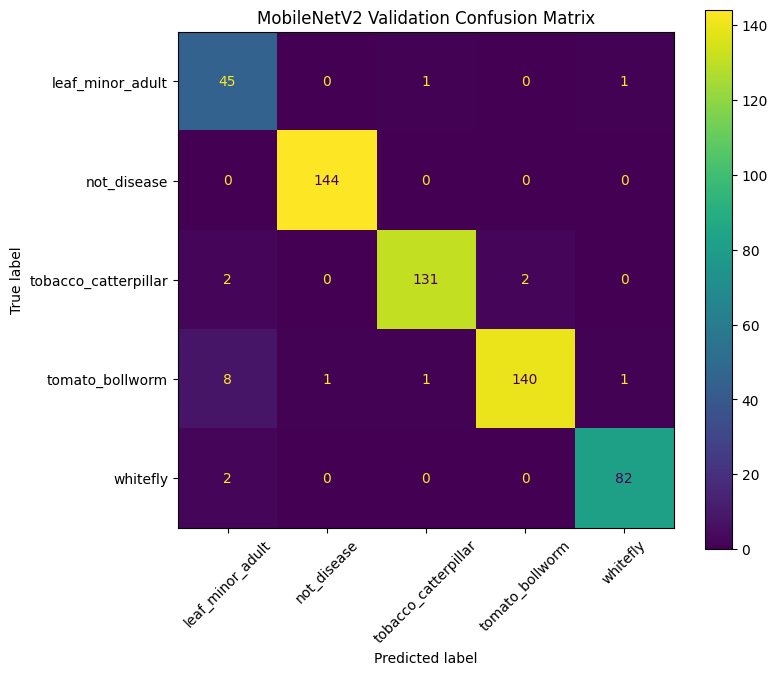

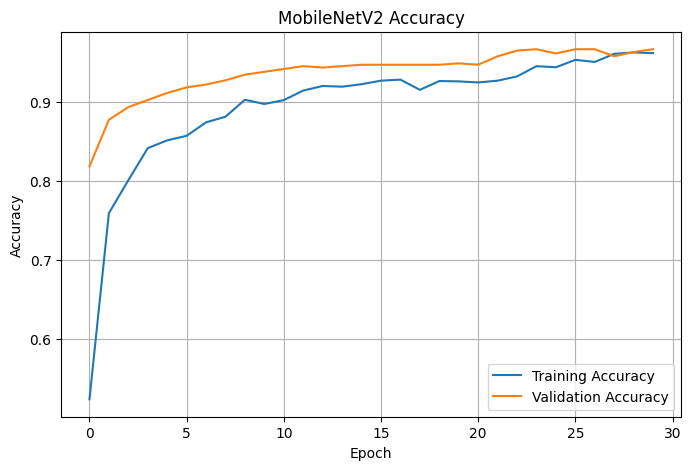

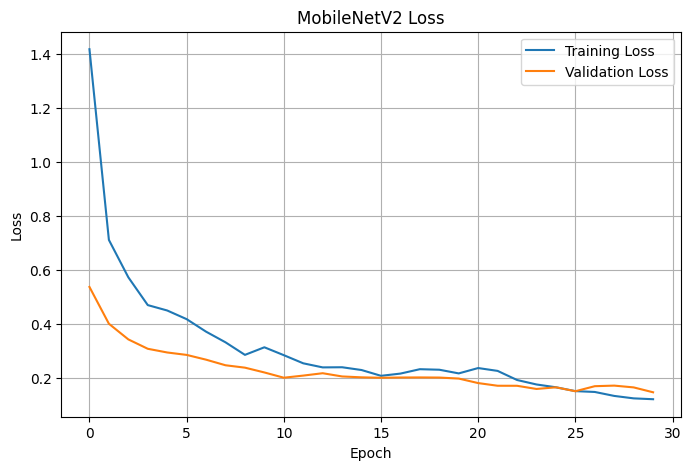

In [16]:
# ============================================================
# 16. TRAIN MODEL
# ============================================================

results = []

# Train MobileNetV2 first. This is best for a small dataset.
mobilenet_result = train_model("MobileNetV2")
results.append(mobilenet_result)

# Optional: train EfficientNetB0 after MobileNetV2.
if TRAIN_EFFICIENTNETB0_TOO:
    efficientnet_result = train_model("EfficientNetB0")
    results.append(efficientnet_result)


In [17]:
# ============================================================
# 17. FINAL MODEL COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("Final Model Comparison")
print("=" * 60)

for result in results:
    print(
        f"{result['model_name']} "
        f"--> Validation Accuracy: {result['validation_accuracy'] * 100:.2f}% "
        f"| Validation Loss: {result['validation_loss']:.4f} "
        f"| Saved Model: {result['model_path']}"
    )

best_result = max(results, key=lambda x: x["validation_accuracy"])

print("\nBest model:")
print(best_result["model_name"])
print(f"Best validation accuracy: {best_result['validation_accuracy'] * 100:.2f}%")
print(f"Saved model path: {best_result['model_path']}")



Final Model Comparison
MobileNetV2 --> Validation Accuracy: 96.61% | Validation Loss: 0.1480 | Saved Model: best_MobileNetV2.keras

Best model:
MobileNetV2
Best validation accuracy: 96.61%
Saved model path: best_MobileNetV2.keras


In [18]:
# ============================================================
# 18. SINGLE IMAGE PREDICTION
# ============================================================

def predict_single_image(image_path, model_path="best_MobileNetV2.keras"):
    model = tf.keras.models.load_model(model_path)

    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = tf.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)[0]
    predicted_index = int(np.argmax(prediction))
    confidence = float(np.max(prediction))

    print("Predicted class:", CLASS_NAMES[predicted_index])
    print("Confidence:", round(confidence * 100, 2), "%")

    return CLASS_NAMES[predicted_index], confidence

# Example:
# predict_single_image(r"C:\Users\YourName\Desktop\test_image.jpg")
